In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.offline as pyo
import plotly.express as px
import plotly.graph_objects as go

pyo.init_notebook_mode(connected = True)
pd.options.plotting.backend = 'plotly'

In [67]:
df = yf.download(['^TNX', 'GC=F'], start = '2015-01-01', end = '2026-01-30').dropna()
df

[*********************100%***********************]  2 of 2 completed


Price             Close                High                 Low         \
Ticker             GC=F   ^TNX         GC=F   ^TNX         GC=F   ^TNX   
Date                                                                     
2015-01-02  1186.000000  2.123  1194.500000  2.213  1169.500000  2.102   
2015-01-05  1203.900024  2.039  1206.900024  2.109  1180.099976  2.037   
2015-01-06  1219.300049  1.963  1220.000000  1.997  1203.500000  1.889   
2015-01-07  1210.599976  1.954  1219.199951  2.008  1210.599976  1.938   
2015-01-08  1208.400024  2.016  1215.699951  2.030  1206.300049  1.988   
...                 ...    ...          ...    ...          ...    ...   
2026-01-23  4976.200195  4.239  4976.200195  4.263  4936.000000  4.233   
2026-01-26  5079.700195  4.213  5095.600098  4.229  5052.200195  4.203   
2026-01-27  5079.899902  4.223  5079.899902  4.239  5079.899902  4.207   
2026-01-28  5301.600098  4.251  5301.600098  4.271  5301.600098  4.235   
2026-01-29  5318.399902  4.227  5586.200195  4.271  5097.500000  4.223   

Price              Open           Volume       
Ticker             GC=F   ^TNX      GC=F ^TNX  
Date                                           
2015-01-02  1184.000000  2.197     138.0  0.0  
2015-01-05  1180.300049  2.102     470.0  0.0  
2015-01-06  1203.500000  1.968      97.0  0.0  
2015-01-07  1219.199951  1.975      29.0  0.0  
2015-01-08  1207.000000  2.004      92.0  0.0  
...                 ...    ...       ...  ...  
2026-01-23  4949.600098  4.237     169.0  0.0  
2026-01-26  5081.500000  4.213     180.0  0.0  
2026-01-27  5079.899902  4.235      34.0  0.0  
2026-01-28  5301.600098  4.235  112054.0  0.0  
2026-01-29  5415.700195  4.247  112054.0  0.0  

[2782 rows x 10 columns]

In [69]:
df.Close

Ticker,GC=F,^TNX
Date,,
2015-01-02,1186.000000,2.123
2015-01-05,1203.900024,2.039
2015-01-06,1219.300049,1.963
2015-01-07,1210.599976,1.954
2015-01-08,1208.400024,2.016
...,...,...
2026-01-23,4976.200195,4.239
2026-01-26,5079.700195,4.213
2026-01-27,5079.899902,4.223


In [133]:
daily_log_returns = np.log(df.Close['GC=F']/df.Close['GC=F'].shift(1)).dropna()
daily_log_returns

Date
2015-01-05    0.014980
2015-01-06    0.012711
2015-01-07   -0.007161
2015-01-08   -0.001819
2015-01-09    0.006270
                ...   
2026-01-23    0.013637
2026-01-26    0.020586
2026-01-27    0.000039
2026-01-28    0.042717
2026-01-29    0.003164
Name: GC=F, Length: 2781, dtype: float64

In [139]:
monthly_gold = log_returns.resample("ME").last()
monthly_gold

Date
2015-01-31    0.018871
2015-02-28    0.002477
2015-03-31   -0.001436
2015-04-30   -0.022909
2015-05-31    0.001094
                ...   
2025-09-30    0.005195
2025-10-31   -0.004785
2025-11-30    0.012668
2025-12-31   -0.010235
2026-01-31    0.003164
Freq: ME, Name: GC=F, Length: 133, dtype: float64

In [137]:
daily_change = df.Close['^TNX'].diff().dropna()
daily_change

Date
2015-01-05   -0.084
2015-01-06   -0.076
2015-01-07   -0.009
2015-01-08    0.062
2015-01-09   -0.045
              ...  
2026-01-23   -0.010
2026-01-26   -0.026
2026-01-27    0.010
2026-01-28    0.028
2026-01-29   -0.024
Name: ^TNX, Length: 2781, dtype: float64

In [141]:
monthly_USbond = daily_change.resample("ME").sum()
monthly_USbond

Date
2015-01-31   -0.448
2015-02-28    0.327
2015-03-31   -0.068
2015-04-30    0.112
2015-05-31    0.049
              ...  
2025-09-30   -0.079
2025-10-31   -0.047
2025-11-30   -0.084
2025-12-31    0.146
2026-01-31    0.064
Freq: ME, Name: ^TNX, Length: 133, dtype: float64

In [155]:
combined = pd.concat([monthly_gold, monthly_USbond], axis=1)
combined

,GC=F,^TNX
Date,,
2015-01-31,0.018871,-0.448
2015-02-28,0.002477,0.327
2015-03-31,-0.001436,-0.068
2015-04-30,-0.022909,0.112
2015-05-31,0.001094,0.049
...,...,...
2025-09-30,0.005195,-0.079
2025-10-31,-0.004785,-0.047
2025-11-30,0.012668,-0.084


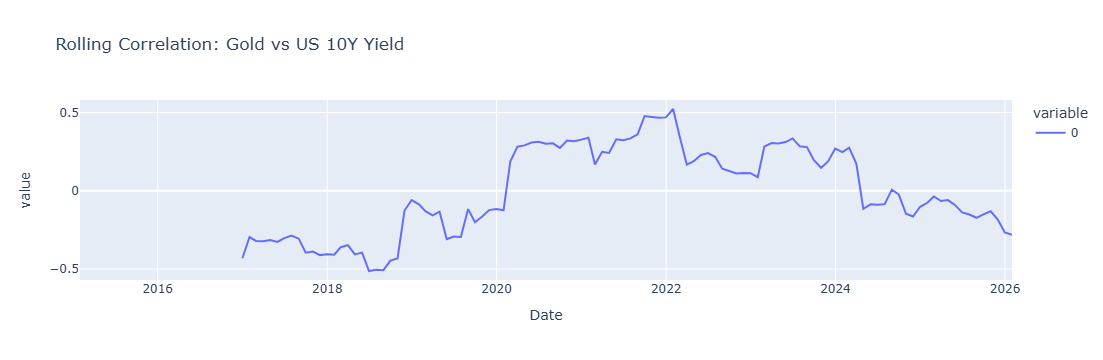

In [161]:
rolling_corr = combined['GC=F'].rolling(24).corr(combined['^TNX'])
rolling_corr.plot(title = "Rolling Correlation: Gold vs US 10Y Yield")